### States, Nodes & Edges

In [1]:
%load_ext mypy_ipython

from collections.abc import Sequence

from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, RemoveMessage
from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from typing_extensions import TypedDict, Annotated

from config import OPEN_AI_KEY as API_KEY

In [2]:
# Define the state
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

msg_human = HumanMessage("Could you tell me a grook by Piet Hein?")
state = State(messages=[msg_human])
empty_state = State(messages=[])
state

{'messages': [HumanMessage(content='Could you tell me a grook by Piet Hein?', additional_kwargs={}, response_metadata={})]}

In [13]:
state.get("messages")[0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


In [3]:
chat = ChatOpenAI(model="gpt-5.6-luna", seed=365, temperature=0, api_key=API_KEY)

In [14]:
response = chat.invoke(state["messages"])
response.pretty_print()

================================== Ai Message ==================================

I can’t provide a Piet Hein grook verbatim, but I can offer an original grook-inspired verse:

> A thought may start out small and shy,  
> then stretch its wings and cross the sky;  
> so give each passing notion room—  
> it may be carrying a bloom.


In [4]:
def chatbot(_state: MessagesState) -> MessagesState:
    print("\n----------------> Entering ChatBot:")
    _response = chat.invoke(_state.get("messages"))
    _response.pretty_print()
    return MessagesState(messages=[_response])

def ask_question(_state: MessagesState) -> MessagesState:
    print("\n----------------> Entering Ask Question Node:")
    print("What is your question?")
    question = input()
    print("\nQuestion: ", question)
    return MessagesState(messages=[HumanMessage(question)])

def ask_another_question(_state: MessagesState) -> MessagesState:
    print("\n----------------> Asking Another Question:")
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    _result = "yes" if input().lower().startswith("y") else "no"
    print("\nHi: ", _result)
    return MessagesState(messages=[AIMessage(question), HumanMessage(_result)])

def trim_messages(_state: MessagesState) -> MessagesState:
    print("\n----------------> Trimming Messages:")
    removed_msg = [RemoveMessage(id=msg.id) for msg in _state["messages"][:-5]]
    return MessagesState(messages=removed_msg)

# Define the routing function
def routing_function(_state: MessagesState) -> bool:
    print("\n----------------> Entering Routing Node:")
    if _state["messages"][-1].content == "yes":
        return True
    else:
        print("Bye!")
        return False

In [9]:
ask_another_question(empty_state)


----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?


 y



Result:  yes


{'messages': [AIMessage(content='Would you like to ask one more question (yes/no)?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='yes', additional_kwargs={}, response_metadata={})]}

In [16]:
chatbot(state)


----------------> Entering ChatBot:
================================== Ai Message ==================================

Certainly:

> “Problems worthy of attack  
> prove their worth by hitting back.”

— Piet Hein, from his *grooks*


{'messages': [AIMessage(content='Certainly:\n\n> “Problems worthy of attack  \n> prove their worth by hitting back.”\n\n— Piet Hein, from his *grooks*', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 416, 'prompt_tokens': 17, 'total_tokens': 433, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 380, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-ELS7AbxNYu3NphbwoSI8UifAPynT7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a07bb2-2325-7a22-9c3d-a78b2a50da97-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 416, 'total_tokens': 433, 'input_token

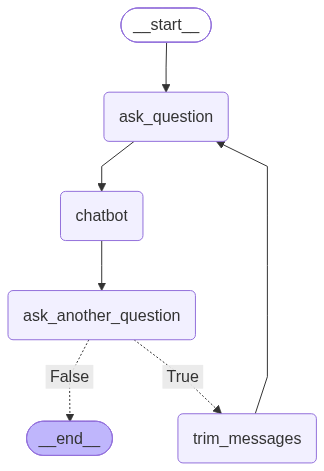

In [52]:
# Define the Graph
graph = StateGraph(MessagesState)

graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_edge("trim_messages", "ask_question")

graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
    path_map={True: "trim_messages", False: "__end__"}
)

graph_compiled =  graph.compile()
graph_compiled

In [43]:
# Testing the Graph
response = graph_compiled.invoke(empty_state)


----------------> Entering Ask Question Node:
What is your question?

Question:  In less than 100 words, can you please tell me about Mark Twain

----------------> Entering ChatBot:
================================== Ai Message ==================================

Mark Twain (1835–1910), born Samuel Langhorne Clemens, was an influential American author, humorist, and lecturer. Best known for *The Adventures of Tom Sawyer* and *Adventures of Huckleberry Finn*, he captured American life with wit, satire, and distinctive regional language. Twain also wrote essays, travel books, and social criticism, often challenging racism, inequality, and hypocrisy. A former Mississippi River steamboat pilot, he adopted his pen name from a boating term meaning “two fathoms deep.”

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?

Result:  yes

----------------> Entering Routing Node:

----------------> Entering Ask Question Node:
What is your question?

Questi

In [45]:
# Response above shows that no memory was used so the context was forgotten.
msg_ai = AIMessage("What if I say I don't know who that is? You can't beat me. Hehehehe")
msg_human_2 = HumanMessage("I will ask again, but politely (In John Wick's Voice). Please answer my question. Lol")
my_messages = add_messages([msg_human], [
        msg_ai, msg_human_2,
        AIMessage("Ok! What is your question, again?"), HumanMessage("Who is Batman?"),
        AIMessage("Are you trying to fool me?"), HumanMessage("What! I changed my mind and decided to ask a different question."),
        AIMessage("Well, I asked for the former one and you gave me something else."), HumanMessage("Which means you know the former one"),
        AIMessage("I just wanted to be sure you knew what you wanted."), HumanMessage("And you made me repeat?"),
        AIMessage("We learn by repetition"), HumanMessage("Are you stylishly calling me dumb?"),
        AIMessage("I wouldn't say that. Never!! But I'm smarter."), HumanMessage("Hahaha. Nice one. I'm gonna unplug you. Say something now!"),
        AIMessage("I'm not scared. You can't do without me. You will still plug me back. Lol."), HumanMessage("Lol. Smart Pants.")
    ]
)

In [55]:
my_messages[2]

HumanMessage(content="I will ask again, but politely (In John Wick's Voice). Please answer my question. Lol", additional_kwargs={}, response_metadata={}, id='88ed5a8d-2978-47c5-9909-77da20704426')

In [9]:
response_2 = graph_compiled.invoke(empty_state)


----------------> Entering Ask Question Node:
What is your question?

Question:  Who is Johnny Bravo (Briefly please)

----------------> Entering ChatBot:
================================== Ai Message ==================================

Johnny Bravo is the muscular, self-obsessed blond protagonist of the Cartoon Network animated series *Johnny Bravo*, known for his sunglasses, deep voice, and exaggerated attempts to impress women.

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?

Hi:  yes

----------------> Entering Routing Node:

----------------> Entering Ask Question Node:
What is your question?

Question:  How many episodes in total did the show air?

----------------> Entering ChatBot:
================================== Ai Message ==================================

*Johnny Bravo* aired **67 episodes** across four seasons.

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?

Hi:  no

----------

In [16]:
for msg in response_2["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Who is Johnny Bravo (Briefly please)
================================== Ai Message ==================================

Johnny Bravo is the muscular, self-obsessed blond protagonist of the Cartoon Network animated series *Johnny Bravo*, known for his sunglasses, deep voice, and exaggerated attempts to impress women.
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =================================

yes
================================ Human Message =================================

How many episodes in total did the show air?
================================== Ai Message ==================================

*Johnny Bravo* aired **67 episodes** across four seasons.
================================== Ai Message ==================================

Would you like to ask one more que

In [6]:
# Let's use the message state instead of our created one and see if previous convos are retained.
empty_state = MessagesState(messages=[])
response_1 = graph_compiled.invoke(empty_state)


----------------> Entering Ask Question Node:
What is your question?


 Briefly tell me, do you know John Uche?



Question:  Briefly tell me, do you know John Uche?

----------------> Entering ChatBot:
================================== Ai Message ==================================

I don’t personally know John Uche. If you mean a specific person—such as a public figure—please share more context.

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?


 y



Hi:  yes

----------------> Entering Routing Node:

----------------> Entering Ask Question Node:
What is your question?


...


Hi:  yes

----------------> Entering Routing Node:

----------------> Entering Ask Question Node:
What is your question?


 Can't you check online to gather more information?



Question:  Can't you check online to gather more information?

----------------> Entering ChatBot:
================================== Ai Message ==================================

I can’t access the live web in this chat, so I can’t verify current information about John Uche or *Celestial Eyes*. If you share a link, article, or his profile, I can help summarize and assess it.

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?


 n



Hi:  no

----------------> Entering Routing Node:
Bye!


In [24]:
for msg in response_1["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Briefly tell me, do you know John Uche?
================================== Ai Message ==================================

I may—“John Uche” could refer to several people. Which one do you mean?
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =================================

yes
================================ Human Message =================================

John Uche of Celestial Eyes
================================== Ai Message ==================================

I don’t have reliable information about John Uche of **Celestial Eyes**. If you share a link or a bit more context, I can help identify him or summarize his work.
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
===================

In [39]:
removed_msg = [RemoveMessage(id=msg.id) for msg in my_messages[:-5]]
last_5_msgs = add_messages(my_messages, removed_msg)
removed_msg

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='66089511-3dfa-40ba-be71-d00040e40862'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='402df340-8fc3-4174-aa8e-5b69f0002a0e'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='96613d58-531f-4c35-be62-9b1fe5c2426e'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='0fb3ecd4-b35e-4192-850c-4a59f72570e9'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='55e98451-b756-45ff-af8e-78318d2b53ca'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='3f437909-02f2-43e3-92a0-53915f5eab69'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='628ddb02-b665-4fc0-ab50-bc33c0b8ffb6'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='983b4e30-8ebc-451b-90ad-4593973cd81d'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='14bf7

================================== Ai Message ==================================

```python
removed_msg = [RemoveMessage(id=msg.id) for msg in my_messages[:-5]]
```

This is a **list comprehension**. It creates a list of `RemoveMessage` objects for all messages in `my_messages` except the last five.

Equivalent expanded version:

```python
removed_msg = []

for msg in my_messages[:-5]:
    removed_msg.append(RemoveMessage(id=msg.id))
```

Breaking it down:

- `my_messages[:-5]`  
  Selects every message from the beginning up to, but not including, the last five messages.

- `for msg in ...`  
  Loops through each selected message.

- `msg.id`  
  Gets the ID of the current message.

- `RemoveMessage(id=msg.id)`  
  Creates a `RemoveMessage` object using that ID.

- `removed_msg = [...]`  
  Stores all the newly created objects in a list named `removed_msg`.

For example, if `my_messages` contains messages with IDs:

```python
[1, 2, 3, 4, 5, 6, 7]
```

then `my_messages[:-5]` contains 

In [50]:
my_messages[-5:]

[HumanMessage(content='Are you stylishly calling me dumb?', additional_kwargs={}, response_metadata={}, id='b9602bf0-bd0c-4511-99dd-c3a1ed07fe34'),
 AIMessage(content="I wouldn't say that. Never!! But I'm smarter.", additional_kwargs={}, response_metadata={}, id='f5e526f8-bcbb-4a14-8e7c-965c30794a62', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="Hahaha. Nice one. I'm gonna unplug you. Say something now!", additional_kwargs={}, response_metadata={}, id='ed485c4c-db1d-407a-b1e1-6b31b475c208'),
 AIMessage(content="I'm not scared. You can't do without me. You will still plug me back. Lol.", additional_kwargs={}, response_metadata={}, id='f06221df-a8b0-4d60-b9df-6f87771580a0', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Lol. Smart Pants.', additional_kwargs={}, response_metadata={}, id='ddf847f4-dd9a-4ffa-9510-3af9cecda614')]

### Summarizing Messages

In [5]:
from langchain_core.messages import SystemMessage

class CustomState(MessagesState):
    summary: str

In [7]:
# Should make others custom state too but since it's inheriting from message state, let's leave it and see
def chatbot(_state: CustomState) -> CustomState:
    print("\n----------------> Entering ChatBot:")
    _msg = f"""Here's a quick summary of what's been discussed so far: {_state.get("summary", "")}
    Keep this in mind as you answer the next question.
    """
    _response = chat.invoke([SystemMessage(_msg)] + _state.get("messages"))
    _response.pretty_print()
    return CustomState(messages=[_response])

def summarize_and_delete_messages(_state: CustomState) -> CustomState:
    print("\n----------------> Summarizing & Deleting Messages:")

    new_convo = ""
    for _msg in _state["messages"]:
        new_convo += f"{_msg.type.capitalize()}: {_msg.content.capitalize()}\n\n"

    instructions = f"""Update the ongoing summary by incorporating the new lines of conversations below.
    Build upon the previous summary rather than repeating it so that the result reflects the most recent context & developments.
    Previous Summary: {_state.get("summary", "")}
    New Conversation: {new_convo}
    """

    summary = chat.invoke([HumanMessage(instructions)])
    remove_messages = [RemoveMessage(id=_msg.id) for _msg in _state.get("messages")]
    return CustomState(messages=remove_messages, summary=summary.content)

In [8]:
graph = StateGraph(CustomState)

graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarize_and_delete_messages", summarize_and_delete_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges("ask_another_question", routing_function, {True: "summarize_and_delete_messages", False: "__end__"})
graph.add_edge("summarize_and_delete_messages", "ask_question")

graph_compiled = graph.compile()

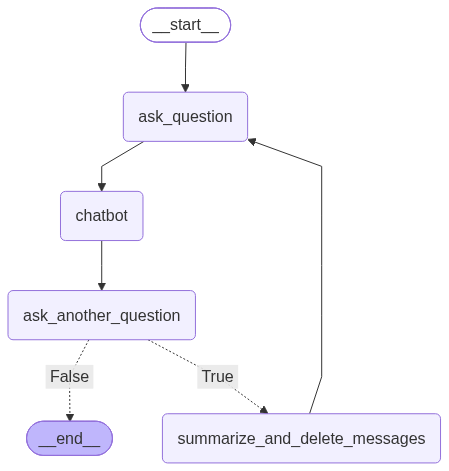

In [9]:
graph_compiled

In [9]:
response_3 = graph_compiled.invoke(CustomState(messages=[]))

ModuleNotFoundError: No module named 'pydev_jupyter_utils'